# Analysis of survey responses
Felix Zaussinger | 08.09.2022

**Core Analysis Goal(s)**
1. Download survey responses via Qualtrics API
2. Merge responses into single file and join GBN classification
3. Create plots to visualize agreement with GBN classification

**Key Insight(s)**
1. Matching of occupation descriptions is a complete fucking mess due to encoding
issues and other extreme fuckshit!!!!!!!!!!!!!!!!!!!!¨¨
2.
3.

In [324]:
import os
import sys
import logging
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from src import utils, plotting_utils, stats_utils
#import mapping_career_causeways

# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload

# OPTIONAL: always reload modules so that as you change code in src, it gets loaded
%autoreload 2

# Settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

sns.set_context("paper")
#sns.set(rc={'figure.figsize': (16, 9.)})
sns.set_style("ticks")

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 120)
pd.options.display.float_format = '{:,.2f}'.format

logging.basicConfig(level=logging.INFO, stream=sys.stdout)

# load paths
useful_paths = utils.UsefulPaths()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Data preprocessing

#### Read final classifications

In [325]:
df_sl = pd.read_csv(
    os.path.join(useful_paths.data_processed, "esco", "esco_level_gbn_classification_short_lists.csv"),
    index_col=0
)

df_sl_tobi = pd.read_csv(
    os.path.join(useful_paths.data_processed, "esco", "esco_level_gbn_classification_short_lists_tobi.csv"),
    index_col=0
)

In [348]:
df_sl_tobi.groupby("gbn_classification_short_list").count()

,conceptUri,preferredLabel,description,gbn_classification_esco,gbn_classification_esco_ess
gbn_classification_short_list,,,,,
brown,63,63,63,63,63
green,91,91,91,91,91
neutral,2854,2854,2854,2854,2853


#### Import contact list with survey id's

In [326]:
contact_list = pd.read_excel(
    os.path.join(useful_paths.data_processed, "survey", "contact_list_survey_v2.xlsx"),
    sheet_name="Survey Links"
)
contact_list

,sample_version,sample_name,survey_name,survey_link,survey_id,random_assignment,random_assignment_corr,email_sent,response,done,note,deadline
0,test_set_v4,test_set_shuffled_1,Green-Occupations_test_set_shuffled_1,https://descil.eu.qualtrics.com/jfe/form/SV_8A...,SV_8AnGiDhFo6NHmuy,EMPL-ESCO-SECRETARIAT@ec.europa.eu,marieke.vandeweyer@oecd.org,Y,Y,NaN,NaN,NaT
1,test_set_v4,test_set_shuffled_2,Green-Occupations_test_set_shuffled_2,https://descil.eu.qualtrics.com/jfe/form/SV_1Z...,SV_1ZcgN17YT4K4ckK,Stelina.Chatzichristou@cedefop.europa.eu,Abdelfeteh.BITAT@ec.europa.eu,Y,NaN,NaN,NaN,NaT
2,test_set_v4,test_set_shuffled_3,Green-Occupations_test_set_shuffled_3,https://descil.eu.qualtrics.com/jfe/form/SV_8B...,SV_8B2nwzLWJJK012S,cath.sleeman@nesta.org.uk,markus.janser@iab.de,Y,Y,NaN,NaN,NaT
3,test_set_v4,test_set_shuffled_4,Green-Occupations_test_set_shuffled_4,https://descil.eu.qualtrics.com/jfe/form/SV_08...,SV_08SzuShq3d0bTHE,markus.janser@iab.de,davide.consoli@ingenio.upv.es,Y,NaN,Y,NaN,NaT
4,test_set_v4,test_set_shuffled_5,Green-Occupations_test_set_shuffled_5,https://descil.eu.qualtrics.com/jfe/form/SV_56...,SV_56bMHSHFEYef2MC,montt@ilo.org,Stelina.Chatzichristou@cedefop.europa.eu,Y,Declined,NaN,3 partial responses,NaT
5,test_set_v4,test_set_shuffled_6,Green-Occupations_test_set_shuffled_6,https://descil.eu.qualtrics.com/jfe/form/SV_eU...,SV_eURBW8C8gggqXxs,u.scharf@skilllab.io,valeria.costantini@uniroma3.it,Y,Y,Y,NaN,NaT
6,test_set_v4,test_set_shuffled_7,Green-Occupations_test_set_shuffled_7,https://descil.eu.qualtrics.com/jfe/form/SV_7O...,SV_7O0vzMVe4r4VEXQ,s.schmid@skilllab.io,s.schmid@skilllab.io,Y,Y,NaN,NaN,NaT
7,test_set_v4,test_set_shuffled_8,Green-Occupations_test_set_shuffled_8,https://descil.eu.qualtrics.com/jfe/form/SV_0c...,SV_0c97zs7xtCbhvr8,elisa.lanzi@oecd.org,Matteo.SOSTERO@ec.europa.eu,Y,NaN,NaN,NaN,NaT
8,test_set_v4,test_set_shuffled_9,Green-Occupations_test_set_shuffled_9,https://descil.eu.qualtrics.com/jfe/form/SV_cF...,SV_cFUdmL9WmkTECa2,valeria.costantini@uniroma3.it,montt@ilo.org,Y,NaN,NaN,NaN,NaT
9,test_set_v4,test_set_shuffled_10,Green-Occupations_test_set_shuffled_10,https://descil.eu.qualtrics.com/jfe/form/SV_be...,SV_behR8jDZYKRWfMq,Vlasis.KOROVILOS@cedefop.europa.eu,EMPL-ESCO-SECRETARIAT@ec.europa.eu,Y,NaN,NaN,NaN,NaT


#### Setup Qualtrics API connection

In [327]:
from QualtricsAPI.Setup import Credentials
from QualtricsAPI.Survey import Responses
responses = Responses()

#Call the qualtrics_api_credentials() method (Non-XM Directory Users)
Credentials().qualtrics_api_credentials(
    token='r6EycR7p7xwUqMJtYKEZO8NvVsyeQJmjKj7u5uJB',
    data_center='fra1'
)

#### Iteratively download raw responses

In [328]:
header = None
response_container = []
for i, survey_id in enumerate(contact_list.survey_id):
    print("downloading survey: {}/{}".format(i+1, len(contact_list.survey_id)))
    #Get Survey Responses (Updated)
    response = responses.get_survey_responses(
        survey=survey_id, useLabels=True
    )

    # append nan row for empty responses
    if response.shape[0] < 3:
        response.loc[2, :] = np.nan

    # set survey id
    response["SurveyId"] = survey_id

    response_container.append(response)

downloading survey: 1/21
downloading survey: 2/21
downloading survey: 3/21
downloading survey: 4/21
downloading survey: 5/21
downloading survey: 6/21
downloading survey: 7/21
downloading survey: 8/21
downloading survey: 9/21
downloading survey: 10/21
downloading survey: 11/21
downloading survey: 12/21
downloading survey: 13/21
downloading survey: 14/21
downloading survey: 15/21
downloading survey: 16/21
downloading survey: 17/21
downloading survey: 18/21
downloading survey: 19/21
downloading survey: 20/21
downloading survey: 21/21


#### Clean raw data

In [329]:
# reset index to obtain row id's
df_raw = pd.concat(response_container).reset_index()
df_raw = df_raw.rename(columns={"index": "RowId"})

# drop rows with dict's
df_clean = df_raw[df_raw["RowId"] != 1]

# drop cols we don't need, rename
cols2drop = ["RecipientLastName", "RecipientFirstName", "RecipientEmail", "ExternalReference", "Q1.1"]
rename_dict = {"Q2.1": "RecipientName", "Q2.2": "RecipientEmail", "Q2.3": "RecipientInstitution"}
df_clean = df_clean.drop(columns=cols2drop)
df_clean = df_clean.rename(columns=rename_dict)
df_clean = df_clean.drop_duplicates()

df_clean

,RowId,StartDate,EndDate,Status,IPAddress,Progress,Duration (in seconds),Finished,RecordedDate,ResponseId,LocationLatitude,LocationLongitude,DistributionChannel,UserLanguage,Q1.2_Browser,Q1.2_Version,Q1.2_Operating System,Q1.2_Resolution,Q1.3_First Click,Q1.3_Last Click,Q1.3_Page Submit,Q1.3_Click Count,RecipientName,RecipientEmail,RecipientInstitution,Q2.4_First Click,Q2.4_Last Click,Q2.4_Page Submit,Q2.4_Click Count,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,SurveyId
0,0,Start Date,End Date,Response Type,IP Address,Progress,Duration (in seconds),Finished,Recorded Date,Response ID,Location Latitude,Location Longitude,Distribution Channel,User Language,Click to write the question text - Browser,Click to write the question text - Version,Click to write the question text - Operating S...,Click to write the question text - Resolution,Timing - First Click,Timing - Last Click,Timing - Page Submit,Timing - Click Count,Please enter your first and last name.,Please enter your email address.,Which institution are you affiliated with?,Timing - First Click,Timing - Last Click,Timing - Page Submit,Timing - Click Count,Waste and scrap distribution managers plan the...,Pesticide mixers operate and maintain machines...,Airside safety managers supervise the airside ...,Tyre vulcanisers repair tears and holes in cas...,Solar energy sales consultants provide advice ...,Hazardous materials inspectors inspect facilit...,Water treatment plant managers supervise water...,Compression moulding machine operators set up ...,Oil rig motorhands assume responsibility for t...,Forestry advisers provide services and advice ...,Surface grinding machine operators set up and ...,Environmental technicians investigate sources ...,Drillers set up and operate drilling rigs and ...,Natural resources consultant provide advice on...,Fisheries observers record and report on fishi...,Fibreglass machine operators control and maint...,Quarry engineers analyse which extraction meth...,Insurance product managers set and direct the ...,Chief data officers manage companies' enterpri...,Airport environment officers monitor environme...,Power lines supervisors monitor the constructi...,Asbestos abatement workers remove asbestos fro...,Oxy fuel burning machine operators set up and ...,Electroplating machine operators set up and te...,Animal artificial insemination technicians are...,Energy analysts evaluate the consumption of en...,"Taxi controllers take bookings, dispatch vehic...",Economic policy officers develop economic stra...,Private chefs comply with food and sanitation ...,Nailing machine operators work with machines t...,SV_8AnGiDhFo6NHmuy
2,2,2022-09-09 14:30:05,2022-09-09 14:41:43,IP Address,78.41.129.20,100,698,True,2022-09-09 14:41:45,R_QicrS1sJXQLcgAV,48.8323,2.4075,anonymous,EN,Edge,105.0.1343.27,Windows NT 10.0,1280x720,81.2,81.2,89.379,1,Marieke Vandeweyer,marieke.vandeweyer@oecd.org,OECD,1.654,15.624,16.618,5,Green,Neutral,Brown,Neutral,Green,Neutral,Green,Neutral,Neutral,Green,Neutral,Green,Neutral,Green,Green,Neutral,Brown,Neutral,Neutral,Green,Neutral,Neutral,Unsure,Neutral,Green,Green,Brown,Neutral,Neutral,Neutral,SV_8AnGiDhFo6NHmuy
3,0,Start Date,End Date,Response Type,IP Address,Progress,Duration (in seconds),Finished,Recorded Date,Response ID,Location Latitude,Location Longitude,Distribution Channel,User Language,Click to write the question text - Browser,Click to write the question text - Version,Click to write the question text - Operating S...,Click to write the question text - Resolution,Timing - First Click,Timing - Last Click,Timing - Page Submit,Timing - Click Count,Please enter your first and last name.,Please enter your email address.,Which institution are you affiliated with?,Timing - First Click,Timing - Last Click,Timing - Page Submit,Timing - Click Count,Asbestos abatement workers remove asbestos fro...,Economic policy officers develop economic stra...,Drillers set up and operate drilling rigs and ...,T

In [330]:
# this snippet needs to be deleted from every occupation description (drop down menu
# from survey)
del_desc = "\n\n\n\n\nDisplay definitions\n\n\nDefinitions:\n\nGreen occupations: contribute to decreasing the negative impact of human activity on the environment (e.g., through reducing GHG emissions, air- & water-pollution, restoring ecosystems or enhancing biodiversity) or to enabling the green transition (e.g., through expanding the electricity transmission & distribution network), and are predominantly found in key green economy sectors (e.g., Renewable Energy Generation, Energy Efficiency, Environment Protection, Recycling and Waste Reduction, Water Supply).\nBrown occupations: contribute to maintaining or increasing the negative impact of human activity on the environment (e.g., through emitting GHG's, causing air- & water-pollution, damaging ecosystems or reducing biodiversity) and are predominantly found in sectors with above-average emission & pollution intensities (e.g., Mining, Oil and Gas Extraction, Manufacturing).\nNeutral occupations: neither contribute to significantly decreasing nor increasing the negative impact of human activity on the environment and neither affect the direction nor speed of the green transition to a first order (e.g., Hairdressers, Translators)."

for i in range(1, 31):
    df_clean["{}".format(i)] = df_clean["{}".format(i)].str.replace(
        pat=del_desc, repl="", regex=False
    )

In [331]:
# organise occupation columns as (str_description, str_choice) tuples
response_container_fmt = []
for i, (id, grp) in enumerate(df_clean.groupby("SurveyId")):
    grp = grp.set_index("RowId")

    # convert to tuples
    for i in range(1, 31):
        grp.loc[2, "{}".format(i)] = (grp.loc[0, "{}".format(i)], grp.loc[2, "{}".format(i)])
        grp_new = grp.loc[2, :]

    # convert/transpose
    if isinstance(grp_new, pd.Series):
        grp_out = grp_new.to_frame().T
    else:
        raise Exception("check")
    grp_out.index = [i]

    response_container_fmt.append(grp_out)

In [332]:
# combine and drop missing surveys
df_clean_fmt = pd.concat(response_container_fmt, axis=0)
df_clean_fmt = df_clean_fmt.dropna(subset=["RecipientName"])

In [333]:
df_clean_fmt

,StartDate,EndDate,Status,IPAddress,Progress,Duration (in seconds),Finished,RecordedDate,ResponseId,LocationLatitude,LocationLongitude,DistributionChannel,UserLanguage,Q1.2_Browser,Q1.2_Version,Q1.2_Operating System,Q1.2_Resolution,Q1.3_First Click,Q1.3_Last Click,Q1.3_Page Submit,Q1.3_Click Count,RecipientName,RecipientEmail,RecipientInstitution,Q2.4_First Click,Q2.4_Last Click,Q2.4_Page Submit,Q2.4_Click Count,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,SurveyId
30,2022-09-01 05:32:14,2022-09-01 05:36:28,IP Address,88.17.130.193,100,254,True,2022-09-01 05:36:30,R_PYTiQdDYfb4UP3r,39.4923,-0.4046,anonymous,EN,Firefox,103.0,Macintosh,2560x1440,0,0,7.245,0,Davide Consoli,davide.consoli@ingenio.upv.es,INGENIO (CSIC-UPV),1.882,1.882,26.499,1,(Ecologists carry out assessments of the healt...,(Environmental education officers are responsi...,(Dry house attendants monitor and maintain the...,(Nitroglycerin neutralisers maintain explosive...,(Airport environment officers monitor environm...,(Furniture upholsterers provide furniture with...,(Sorter labourers sort recyclable materials an...,(Food analysts perform standardised tests to d...,(Wood technology engineers develop materials a...,(Road construction workers perform road constr...,(Environmental geologists study how mineral op...,(Nuclear technicians function as aids to physi...,(Solar energy engineers design systems which g...,(Fermenter operators control and maintain the ...,"(Specialised doctors prevent, diagnose and tre...",(Foundry moulders manufacture cores for metal ...,"(Production potters process and form clay, by ...",(Water plant technicians maintain and repair w...,(Climatologists study the average change in we...,(Ceramic painters design and create visual art...,(Coating machine operators set up and tend coa...,(Dependability engineers ensure the reliabilit...,(Compression moulding machine operators set up...,(Betting managers organise and coordinate the ...,(Countryside officers are responsible for a ra...,(Justices of the peace deal with small claims ...,(Slate mixers operate and maintain slate mixin...,(Slaughterers slaughter animals and process ca...,(Military welfare workers assist families in c...,(Motor vehicle engine assemblers build and ins...,SV_08SzuShq3d0bTHE
30,2022-09-01 14:46:49,2022-09-01 14:51:40,IP Address,92.67.174.249,100,290,True,2022-09-01 14:51:41,R_3qDwnYdBWJpNNUJ,51.9269,4.8323,anonymous,EN,Chrome,104.0.5112.102,Macintosh,1680x1050,0,0,3.8,0,Ulrich Scharf,u.scharf@skilllab.io,SkillLab,1.692,18.342,21.001,6,(Corporate banking managers offer advice on a ...,(Medical device engineering technicians collab...,(Energy analysts evaluate the consumption of e...,(Electrical transmission system operators tran...,(Gas transmission system operators transport e...,(Equine workers provide caring activities for ...,(Performance lighting directors determine what...,(Health psychologists deal with the various as...,(Boilermakers operate a variety of equipment a...,(Quarry engineers analyse which extraction met...,(Energy assessors determine the energy perform...,(Telephone switchboard operators establish tel...,(Drillers set up and operate drilling rigs and...,(Industrial waste inspectors conduct controls ...,(Environmental engineers integrate environment...,(Environmental education officers are responsi...,(Electroplating machine operators set up and t...,(Mine surveyors prepare and maintain mining pl...,(Aquaculture site supervisors supervise produc...,(Airport environment officers monitor environm...,(Mud loggers analyse the drilling fluids after...,(Mining assistants perform routine duties in m...,(Renewable energy sales representatives assess...,"(Grinding machine operators set up, program an...",(Outdoor activities coordinators organise and ...,(Metal planer operators set up and operate a p...,(Renewable energy engineers research alternati...,(On foot aquatic resources collectors collect ...,(Hazardous waste technici

#### Reshape data to long format

- https://stackoverflow.com/questions/29550414/how-can-i-split-a-column-of-tuples-in-a-pandas-dataframe
- `df['a'], df['b'] = df.col.str`

In [334]:
# find value and id cols
occ_class_cols = ["{}".format(i) for i in range(1, 31)]
keep_cols = set(df_clean_fmt.columns.values).difference(set(occ_class_cols))

# melt
df_clean_fmt_long = df_clean_fmt.melt(value_vars=occ_class_cols, id_vars=keep_cols).sort_values("SurveyId")
df_clean_fmt_long["OccupationDescription"], df_clean_fmt_long["RecipientClassification"] = df_clean_fmt_long["value"].str
df_clean_fmt_long = df_clean_fmt_long.drop(labels=["value", "variable"], axis=1)

C:\Users\fzaussinger\AppData\Local\Temp\ipykernel_11332\2518707840.py:7: FutureWarning: Columnar iteration over characters will be deprecated in future releases.
  df_clean_fmt_long["OccupationDescription"], df_clean_fmt_long["RecipientClassification"] = df_clean_fmt_long["value"].str


#### Join our classification(s)

In [335]:
# short list
df_long_merged = pd.merge(
    df_clean_fmt_long, df_sl[["description", "gbn_classification_short_list"]], left_on="OccupationDescription", right_on="description", how="left"
).rename(columns={"gbn_classification_short_list": "EthClassificationWide"})

# short list tobi
df_long_merged = pd.merge(
    df_long_merged, df_sl_tobi[["description", "gbn_classification_short_list"]], left_on="OccupationDescription", right_on="description", how="left"
).rename(columns={"gbn_classification_short_list": "EthClassificationNarrow"})

# drop rows with missing recipient responses
# df_long_merged_clean = df_long_merged.dropna(subset=["RecipientClassification"])
df_long_merged_clean = df_long_merged.drop(labels=["description_x", "description_y"], axis=1)


# to lowercase
df_long_merged_clean["RecipientClassification"] = df_long_merged_clean["RecipientClassification"].str.lower()
print(df_long_merged_clean.shape)

(300, 33)


#### Create final data for analysis

In [336]:
# drop RecipientClassification == unsure
df_long_final = df_long_merged_clean[df_long_merged_clean["RecipientClassification"] != "unsure"]
print("unsure answers: {:.2f}% of {}".format(100 - 100 * (df_long_final.shape[0] / df_long_merged_clean.shape[0]), df_long_merged_clean.shape[0]))

df_long_final.shape

unsure answers: 6.67% of 300


(280, 33)

In [337]:
df_long_final = df_long_final.dropna(subset=["EthClassificationWide"])
df_long_final.shape

(260, 33)

### Data Analysis

#### Calculate confusion matrix for both lists

true (rows), predicted (columns)

In [338]:
from sklearn import metrics
labels = ["green", "brown", "neutral"]

In [339]:
# wide
cm_wide = metrics.confusion_matrix(
    y_true=df_long_final.EthClassificationWide,
    y_pred=df_long_final.RecipientClassification,
    labels=labels,
    normalize="true"
)
df_cm_wide = pd.DataFrame(cm_wide, columns=labels, index=labels)
df_cm_wide

,green,brown,neutral
green,0.83,0.06,0.11
brown,0.00,0.60,0.40
neutral,0.11,0.11,0.78


In [340]:
# narrow
cm_narrow = metrics.confusion_matrix(
    y_true=df_long_final.EthClassificationNarrow,
    y_pred=df_long_final.RecipientClassification,
    labels=labels,
    normalize="true"
)
df_cm_narrow = pd.DataFrame(cm_narrow, columns=labels, index=labels)
df_cm_narrow

,green,brown,neutral
green,0.83,0.06,0.11
brown,0.00,0.80,0.20
neutral,0.06,0.29,0.65


#### Calculate agreement rates per rater & category

Fraction of correctly classified samples across all 3 classes

In [341]:
keep_cols = ["SurveyId", "RecipientName", "RecipientInstitution", "RecipientEmail"]

In [342]:
overall_accuracy = []
for id, df in df_long_final.groupby("SurveyId"):
    df_out = df.head(1)[keep_cols]
    df_out.loc[:, "AccuracyWide"] = metrics.accuracy_score(df.EthClassificationWide, df.RecipientClassification)
    df_out.loc[:, "AccuracyNarrow"] = metrics.accuracy_score(df.EthClassificationNarrow, df.RecipientClassification)

    overall_accuracy.append(df_out)

df_overall_accuracy = pd.concat(overall_accuracy, axis=0)
df_overall_accuracy

,SurveyId,RecipientName,RecipientInstitution,RecipientEmail,AccuracyWide,AccuracyNarrow
1,SV_08SzuShq3d0bTHE,Davide Consoli,INGENIO (CSIC-UPV),davide.consoli@ingenio.upv.es,0.62,0.46
30,SV_0Vuxf3vymniiKOO,Ulrich Scharf,SkillLab,u.scharf@skilllab.io,0.78,0.81
60,SV_6DSmFSXQBkWuzpI,Glenda Quintini,OECD,glenda.quintini@oecd.org,0.86,0.68
90,SV_7O0vzMVe4r4VEXQ,Simon Schmid,SkillLab,s.schmid@skilllab.io,0.69,0.88
121,SV_8AnGiDhFo6NHmuy,Marieke Vandeweyer,OECD,marieke.vandeweyer@oecd.org,0.44,0.63
151,SV_8B2nwzLWJJK012S,Markus Janser,Institute for Employment Research (IAB) of the...,markus.janser@iab.de,0.69,0.73
180,SV_cCSLdXCxRXS6fPg,Nick Pesta,RMI,npesta@rmi.org,1.00,0.77
210,SV_cCtPgQaYVhffBcy,Cath Sleeman,Nesta,cath.sleeman@nesta.org.uk,0.83,0.88
240,SV_cYJ1zIqeMrFVaaW,David Popp,Syracuse University,dcpopp@syr.edu,0.75,0.82
270,SV_eURBW8C8gggqXxs,Valeria Costantini,Roma Tre University,valeria.costantini@uniroma3.it,0.77,0.62


Fraction of correctly classified samples per class

In [343]:
accuracy_by_category_wide = []
reference_classification = "EthClassificationWide"

for id, df in df_long_final.groupby("SurveyId"):
    df_out = df.head(1)[keep_cols]

    for category, sub_df in df.groupby(reference_classification):
        df_out.loc[:, "Accuracy{}".format(category.capitalize())] = metrics.accuracy_score(sub_df[reference_classification], sub_df.RecipientClassification)

    accuracy_by_category_wide.append(df_out)

df_accuracy_by_category_wide = pd.concat(accuracy_by_category_wide, axis=0)
df_accuracy_by_category_wide

,SurveyId,RecipientName,RecipientInstitution,RecipientEmail,AccuracyBrown,AccuracyGreen,AccuracyNeutral
1,SV_08SzuShq3d0bTHE,Davide Consoli,INGENIO (CSIC-UPV),davide.consoli@ingenio.upv.es,0.80,0.67,0.29
30,SV_0Vuxf3vymniiKOO,Ulrich Scharf,SkillLab,u.scharf@skilllab.io,0.62,0.90,0.78
60,SV_6DSmFSXQBkWuzpI,Glenda Quintini,OECD,glenda.quintini@oecd.org,0.90,0.89,0.78
90,SV_7O0vzMVe4r4VEXQ,Simon Schmid,SkillLab,s.schmid@skilllab.io,0.33,0.78,1.00
121,SV_8AnGiDhFo6NHmuy,Marieke Vandeweyer,OECD,marieke.vandeweyer@oecd.org,0.11,0.67,0.56
151,SV_8B2nwzLWJJK012S,Markus Janser,Institute for Employment Research (IAB) of the...,markus.janser@iab.de,0.44,0.78,0.88
180,SV_cCSLdXCxRXS6fPg,Nick Pesta,RMI,npesta@rmi.org,1.00,1.00,1.00
210,SV_cCtPgQaYVhffBcy,Cath Sleeman,Nesta,cath.sleeman@nesta.org.uk,0.57,1.00,0.88
240,SV_cYJ1zIqeMrFVaaW,David Popp,Syracuse University,dcpopp@syr.edu,0.38,0.90,0.90
270,SV_eURBW8C8gggqXxs,Valeria Costantini,Roma Tre University,valeria.costantini@uniroma3.it,0.78,0.80,0.71


In [344]:
accuracy_by_category_narrow = []
reference_classification = "EthClassificationNarrow"

for id, df in df_long_final.groupby("SurveyId"):
    df_out = df.head(1)[keep_cols]

    for category, sub_df in df.groupby(reference_classification):
        df_out.loc[:, "Accuracy{}".format(category.capitalize())] = metrics.accuracy_score(sub_df[reference_classification], sub_df.RecipientClassification)

    accuracy_by_category_narrow.append(df_out)

df_accuracy_by_category_narrow = pd.concat(accuracy_by_category_narrow, axis=0)
df_accuracy_by_category_narrow

,SurveyId,RecipientName,RecipientInstitution,RecipientEmail,AccuracyBrown,AccuracyGreen,AccuracyNeutral
1,SV_08SzuShq3d0bTHE,Davide Consoli,INGENIO (CSIC-UPV),davide.consoli@ingenio.upv.es,1.00,0.67,0.27
30,SV_0Vuxf3vymniiKOO,Ulrich Scharf,SkillLab,u.scharf@skilllab.io,1.00,0.90,0.71
60,SV_6DSmFSXQBkWuzpI,Glenda Quintini,OECD,glenda.quintini@oecd.org,1.00,0.89,0.50
90,SV_7O0vzMVe4r4VEXQ,Simon Schmid,SkillLab,s.schmid@skilllab.io,1.00,0.78,0.93
121,SV_8AnGiDhFo6NHmuy,Marieke Vandeweyer,OECD,marieke.vandeweyer@oecd.org,0.00,0.67,0.69
151,SV_8B2nwzLWJJK012S,Markus Janser,Institute for Employment Research (IAB) of the...,markus.janser@iab.de,0.50,0.78,0.73
180,SV_cCSLdXCxRXS6fPg,Nick Pesta,RMI,npesta@rmi.org,1.00,1.00,0.62
210,SV_cCtPgQaYVhffBcy,Cath Sleeman,Nesta,cath.sleeman@nesta.org.uk,1.00,1.00,0.77
240,SV_cYJ1zIqeMrFVaaW,David Popp,Syracuse University,dcpopp@syr.edu,0.50,0.90,0.86
270,SV_eURBW8C8gggqXxs,Valeria Costantini,Roma Tre University,valeria.costantini@uniroma3.it,1.00,0.80,0.47


### Visualisation

#### Confusion matrix

#### Overall accuracy per rater

#### Per-category accuracy

- swarmplot doesn't recognize hue when either the x or y parameter is omitted: https://github.com/mwaskom/seaborn/issues/941

Reference: Wide ETH classification (SL)

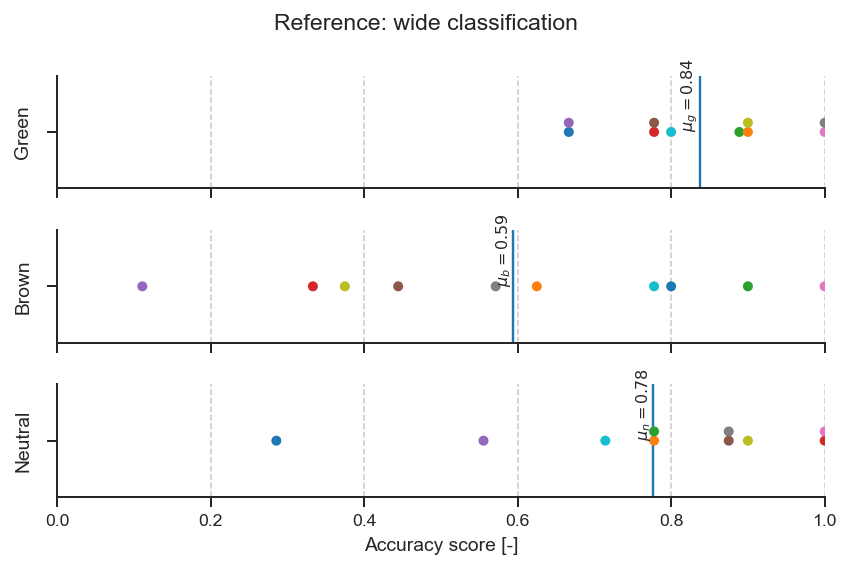

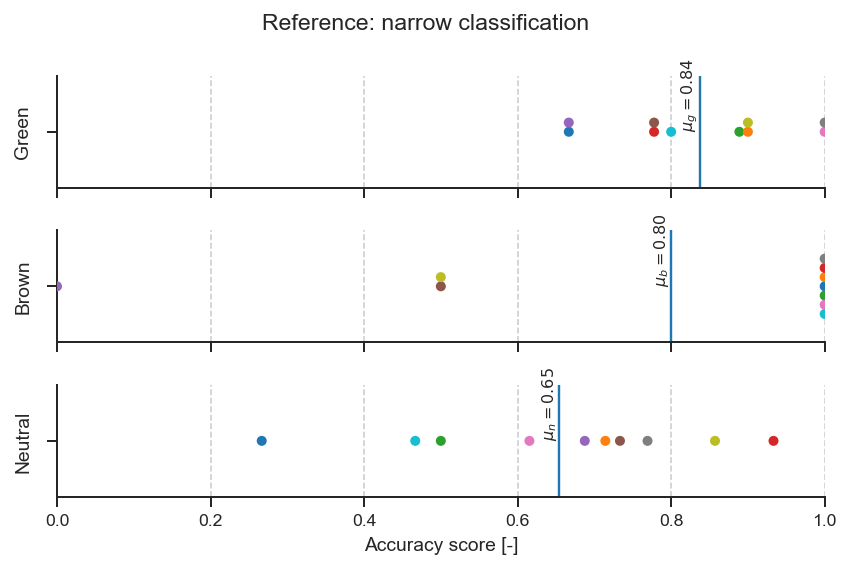

In [346]:
# wide or narrow
dfs = {
    "wide": df_accuracy_by_category_wide,
    "narrow": df_accuracy_by_category_narrow
}

color = None
alpha = 1
show_legend = False

for version, df_plot in dfs.items():

    fig, axes = plt.subplots(nrows=3, sharex=True)

    # swarmplots (one point is one rater)
    sns.swarmplot(y=[""]*len(df_plot), x=df_plot["AccuracyGreen"], hue=df_plot["RecipientName"], color=color, alpha=alpha, ax=axes[0])
    sns.swarmplot(y=[""]*len(df_plot), x=df_plot["AccuracyBrown"], hue=df_plot["RecipientName"], color=color, alpha=alpha, ax=axes[1])
    sns.swarmplot(y=[""]*len(df_plot), x=df_plot["AccuracyNeutral"], hue=df_plot["RecipientName"], color=color, alpha=alpha, ax=axes[2])

    # mean accuracies per category
    mean_acc_green = df_plot["AccuracyGreen"].mean()
    mean_acc_brown = df_plot["AccuracyBrown"].mean()
    mean_acc_neutral = df_plot["AccuracyNeutral"].mean()

    # averages
    axes[0].axvline(mean_acc_green, color=color)
    axes[1].axvline(mean_acc_brown, color=color)
    axes[2].axvline(mean_acc_neutral, color=color)

    # annotations
    y_text = 0
    axes[0].text(mean_acc_green, y_text, "$\mu_g = {:.2f}$".format(mean_acc_green), rotation=90, va='bottom', ha="right", fontsize=8)
    axes[1].text(mean_acc_brown, y_text, "$\mu_b = {:.2f}$".format(mean_acc_brown), rotation=90, va='bottom', ha="right", fontsize=8)
    axes[2].text(mean_acc_neutral, y_text, "$\mu_n = {:.2f}$".format(mean_acc_neutral), rotation=90, va='bottom', ha="right", fontsize=8)

    # labels
    axes[0].set_ylabel("Green")
    axes[0].set_xlabel(None)
    axes[1].set_ylabel("Brown")
    axes[1].set_xlabel(None)
    axes[2].set_ylabel("Neutral")
    axes[2].set_xlabel("Accuracy score [-]")

    # axis
    #plt.xticks(np.arange(0, 1.1, 0.1))
    plt.xlim(0, 1)

    # grid lines
    for ax in axes:
        ax.grid(axis="x", which="major", linestyle="--")

    # legend
    for ax in axes:
        ax.legend([],[], frameon=False)

    if show_legend:
        plotting_utils.move_legend_to_right(axes[1], scale=.6)

    # layout
    plt.suptitle("Reference: {} classification".format(version))
    sns.despine()
    plt.tight_layout()

    # save
    plt.savefig(
        os.path.join(useful_paths.figure_dir, "survey", "classification_accuracy_per_category_{}_legend_{}.png".format(version, show_legend)),
        bbox_inches="tight",
        dpi=300
    )